
# Mental Health Condition Detection from Social Media Text

**Goal**: Build an end-to-end machine learning pipeline to detect a person's mental health condition (e.g., depression, anxiety, stress, etc.) from social media text.


## 1. Setup & Requirements

In [1]:

# Core
import os, re, sys, math, itertools, joblib, warnings, json, time, random
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support)

# Visualization
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print('Python:', sys.version)
print('Pandas:', pd.__version__)


Python: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
Pandas: 2.3.0


In [2]:
!pip install -q sentence-transformers



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.base import TransformerMixin


import numpy as np


## 2. Configuration

In [4]:
DATA_PATH = 'Combined Data.csv'  

TEXT_COLUMN = 'text'   
LABEL_COLUMN = 'label'  

# Train/validation split
TEST_SIZE   = 0.2
RANDOM_STATE = 42

# Whether to drop duplicate texts
DROP_DUPLICATES = True


## 3. Load Data

In [5]:

assert os.path.exists(DATA_PATH), f'File not found: {DATA_PATH}. Please update DATA_PATH above.'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)


Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety


## 4. Sanity Checks & Basic Cleaning

In [6]:
TEXT_COLUMN = "statement"
LABEL_COLUMN = "status"

# Drop unnecessary index column if exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Keep only rows with non-null text and label
if TEXT_COLUMN not in df.columns or LABEL_COLUMN not in df.columns:
    raise ValueError(f"""
TEXT_COLUMN='{TEXT_COLUMN}' or LABEL_COLUMN='{LABEL_COLUMN}' not found.
Please open the CSV to confirm actual column names and update the config.
Columns present: {df.columns.tolist()}
""")

df = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
df = df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])


## 5. Train / Validation Split

In [7]:

X = df[TEXT_COLUMN].astype(str).values
y = df[LABEL_COLUMN].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print('Train size:', len(X_train))
print('Val size:', len(X_val))


Train size: 42144
Val size: 10537


## 6. Text Cleaning Helper

In [8]:

def simple_clean(text):
    """Lightweight cleaner that avoids external downloads:
    - lowercasing
    - remove URLs, emails, numbers, and extra spaces
    - keep basic punctuation
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)           # emails
    text = re.sub(r'[^a-z\s\.!?\,\']', ' ', text)  # keep letters and basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Preview cleaning on a few samples
for t in X_train[:3]:
    print('RAW  :', t[:120])
    print('CLEAN:', simple_clean(t)[:120], '\n')


RAW  : I have not tried them. I do not like the idea of needing pills to be happy my whole life. Why do not some of you guys tr
CLEAN: i have not tried them. i do not like the idea of needing pills to be happy my whole life. why do not some of you guys tr 

RAW  : it says the mayor spends only 11 percent of his time on city duties.
CLEAN: it says the mayor spends only percent of his time on city duties. 

RAW  : i m yo female i just graduated in november and been diagnosed with depression and anxiety i always thought graduating wa
CLEAN: i m yo female i just graduated in november and been diagnosed with depression and anxiety i always thought graduating wa 



## 7. Build Baseline Pipelines (TF–IDF + Models)

In [9]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cpu


Found existing installation: torch 2.2.2+cpu
Uninstalling torch-2.2.2+cpu:
  Successfully uninstalled torch-2.2.2+cpu
Found existing installation: torchvision 0.17.2+cpu
Uninstalling torchvision-0.17.2+cpu:
  Successfully uninstalled torchvision-0.17.2+cpu
Found existing installation: torchaudio 2.2.2+cpu
Uninstalling torchaudio-2.2.2+cpu:
  Successfully uninstalled torchaudio-2.2.2+cpu


You can safely remove it manually.
You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.2.2%2Bcpu-cp312-cp312-win_amd64.whl (200.7 MB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.17.2%2Bcpu-cp312-cp312-win_amd64.whl (1.2 MB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.2.2%2Bcpu-cp312-cp312-win_amd64.whl (2.3 MB)

   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torch]
   ---------------------------------------- 0/3 [torc

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtext 0.18.0 requires torch>=2.3.0, but you have torch 2.2.2+cpu which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:

# Wrapper for semantic embeddings
class SentenceTransformerVectorizer(TransformerMixin):
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return self.model.encode(list(X), show_progress_bar=False)

st_vectorizer = SentenceTransformerVectorizer()

In [11]:
# semantic cells added

In [14]:
pip install -U sentence-transformers transformers



   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.6 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.6 MB 4.6 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.6 MB 5.0 MB/s eta 0:00:02
   --------------- ------------------------ 4.5/11.6 MB 5.5 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/11.6 MB 5.7 MB/s eta 0:00:02
   ----------------------- ---------------- 6.8/11.6 MB 5.7 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.6 MB 5.7 MB/s eta 0:00:01
   ------------------------------- -------- 9.2/11.6 MB 5.6 MB/s eta 0:00:01
   ------------------------------------ --- 10.5/11.6 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/561.5 kB ? eta -:--:--
   ---------------------------------------- 561.5/561.5 kB 6.4 MB/s eta 0:00:00
   ---

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 4.29.0 requires pillow<11.0,>=8.0, but you have pillow 11.3.0 which is incompatible.
gradio 4.29.0 requires typer<1.0,>=0.12; sys_platform != "emscripten", but you have typer 0.9.4 which is incompatible.
gradio 4.29.0 requires urllib3~=2.0, but you have urllib3 1.26.19 which is incompatible.
gradio-client 0.16.1 requires websockets<12.0,>=10.0, but you have websockets 15.0.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

# Load dataset
# df = pd.read_csv("/mnt/data/Combined Data.csv")

# Extract texts and labels
texts = df["statement"].astype(str).tolist()
labels = df["status"].astype(str).tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Initialize embedding transformer
print("Initializing embedding transformer...")
st_model = SentenceTransformer(
    "j-hartmann/emotion-english-distilroberta-base",
    trust_remote_code=True
)

# Paths for saving embeddings
train_path = "X_train_embeddings.npy"
test_path  = "X_test_embeddings.npy"

# Encode or load training embeddings
if os.path.exists(train_path):
    print("Loading saved training embeddings...")
    X_train_embeddings = np.load(train_path)
else:
    print("Encoding training data...")
    X_train_embeddings = st_model.encode(
        X_train,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    np.save(train_path, X_train_embeddings)
    print("Training embeddings saved.")

# Encode or load test embeddings
if os.path.exists(test_path):
    print("Loading saved test embeddings...")
    X_test_embeddings = np.load(test_path)
else:
    print("Encoding test data...")
    X_test_embeddings = st_model.encode(
        X_test,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    np.save(test_path, X_test_embeddings)
    print("Test embeddings saved.")


Initializing embedding transformer...


No sentence-transformers model found with name j-hartmann/emotion-english-distilroberta-base. Creating a new one with mean pooling.
Some weights of RobertaModel were not initialized from the model checkpoint at j-hartmann/emotion-english-distilroberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Encoding training data...


Batches:   0%|          | 0/1317 [00:00<?, ?it/s]

Training embeddings saved.
Encoding test data...


Batches:   0%|          | 0/330 [00:00<?, ?it/s]

Test embeddings saved.


In [18]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Initialize models
logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
svc    = LinearSVC(class_weight='balanced')

# Train or load Logistic Regression
if os.path.exists("logreg_model.pkl"):
    print("Loading saved Logistic Regression model...")
    logreg = joblib.load("logreg_model.pkl")
else:
    print("Training Logistic Regression...")
    logreg.fit(X_train_embeddings, y_train)
    joblib.dump(logreg, "logreg_model.pkl")
    print("Logistic Regression model saved.")

# Train or load LinearSVC
if os.path.exists("svc_model.pkl"):
    print("Loading saved LinearSVC model...")
    svc = joblib.load("svc_model.pkl")
else:
    print("Training LinearSVC...")
    svc.fit(X_train_embeddings, y_train)
    joblib.dump(svc, "svc_model.pkl")
    print("LinearSVC model saved.")

print("✅ Both models trained and embeddings cached.")


Training Logistic Regression...
Logistic Regression model saved.
Training LinearSVC...
LinearSVC model saved.
✅ Both models trained and embeddings cached.


## 8. Evaluation Utilities


=== Embeddings + Logistic Regression ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.7426    0.7474    0.7450       768
             Bipolar     0.5988    0.7302    0.6580       556
          Depression     0.7732    0.5998    0.6756      3081
              Normal     0.9279    0.8859    0.9064      3269
Personality disorder     0.3545    0.7023    0.4711       215
              Stress     0.4512    0.6983    0.5482       517
            Suicidal     0.6360    0.7011    0.6670      2131

            accuracy                         0.7336     10537
           macro avg     0.6406    0.7236    0.6673     10537
        weighted avg     0.7577    0.7336    0.7392     10537

Accuracy: 0.7336053905286135


<Figure size 600x600 with 0 Axes>

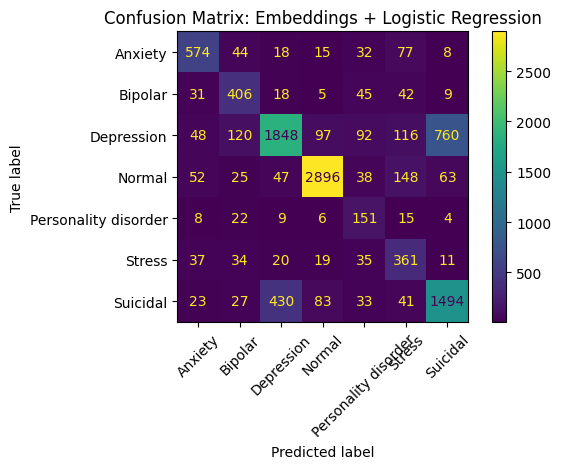


=== Embeddings + Linear SVM ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.6441    0.8438    0.7306       768
             Bipolar     0.6777    0.6241    0.6498       556
          Depression     0.7375    0.6738    0.7042      3081
              Normal     0.9312    0.9027    0.9167      3269
Personality disorder     0.4448    0.6186    0.5175       215
              Stress     0.4744    0.6441    0.5463       517
            Suicidal     0.6676    0.6373    0.6521      2131

            accuracy                         0.7446     10537
           macro avg     0.6539    0.7063    0.6739     10537
        weighted avg     0.7546    0.7446    0.7471     10537

Accuracy: 0.7446142165701812


<Figure size 600x600 with 0 Axes>

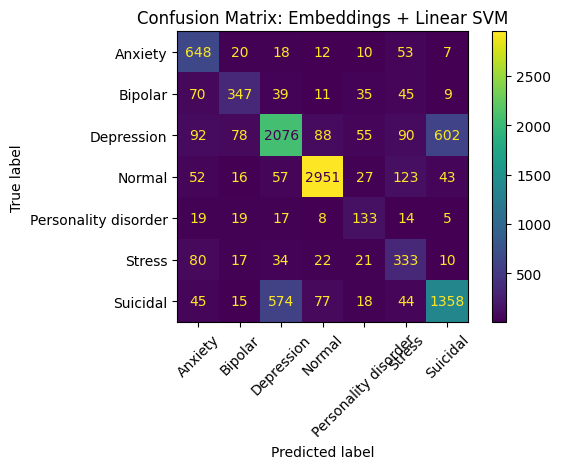

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X_tr, y_tr, X_te, y_te, title='Model'):
    print(f'\n=== {title} ===')
    # Predictions
    y_pred = model.predict(X_te)

    # Report
    print('\nClassification Report:')
    print(classification_report(y_te, y_pred, digits=4))
    print('Accuracy:', accuracy_score(y_te, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred, labels=np.unique(y_te))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_te))
    plt.figure(figsize=(6,6))
    disp.plot(values_format='d', xticks_rotation=45)
    plt.title(f'Confusion Matrix: {title}')
    plt.tight_layout()
    plt.show()

# Evaluate both models on embeddings
evaluate_model(logreg, X_train_embeddings, y_train, X_test_embeddings, y_test, title='Embeddings + Logistic Regression')
evaluate_model(svc,    X_train_embeddings, y_train, X_test_embeddings, y_test, title='Embeddings + Linear SVM')


## 9. Cross-Validation & Learning Curve

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Fix random state
RANDOM_STATE = 42

# Load dataset
DATA_PATH = "Combined Data.csv"
df = pd.read_csv(DATA_PATH)

# Drop index column if exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Clean text column (convert to string and replace NaN)
df['statement'] = df['statement'].astype(str).fillna("")

# Define features (text) and target (labels)
X = df['statement']
y = df['status']

# TF-IDF + Logistic Regression
pipe_logreg = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

# TF-IDF + Linear SVM
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))
])


TF-IDF + Logistic Regression CV f1_macro: 0.7217 ± 0.0039
TF-IDF + Linear SVM CV f1_macro: 0.7345 ± 0.0033


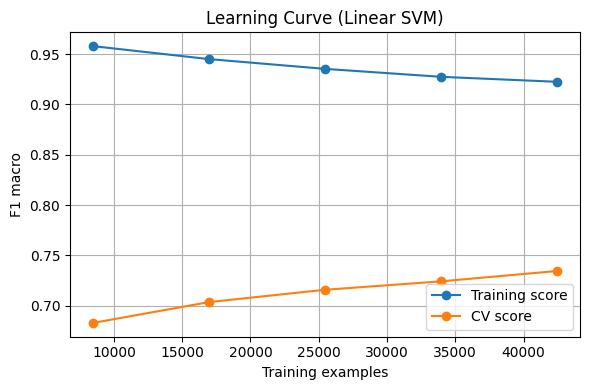

In [33]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_eval(pipe, X, y, name='Model'):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    print(f'{name} CV f1_macro: {scores.mean():.4f} ± {scores.std():.4f}')

# Evaluate both models
cv_eval(pipe_logreg, X, y, 'TF-IDF + Logistic Regression')
cv_eval(pipe_svc,    X, y, 'TF-IDF + Linear SVM')

# Learning Curve (default: Linear SVM as baseline)
train_sizes, train_scores, test_scores = learning_curve(
    pipe_svc, X, y, cv=cv, scoring='f1_macro',
    n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), shuffle=True, random_state=RANDOM_STATE
)

# Compute means
train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

# Plot learning curve
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label='Training score')
plt.plot(train_sizes, test_mean, marker='o', label='CV score')
plt.xlabel('Training examples')
plt.ylabel('F1 macro')
plt.title('Learning Curve (Linear SVM)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Hyperparameter Tuning (GridSearchCV)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params (SVC): {'clf__C': 0.5, 'tfidf__max_features': 80000, 'tfidf__ngram_range': (1, 2)}

=== Best TF-IDF + Linear SVM ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.8017    0.8372    0.8191       768
             Bipolar     0.8071    0.8129    0.8100       556
          Depression     0.7703    0.6803    0.7225      3081
              Normal     0.8883    0.9492    0.9178      3269
Personality disorder     0.7435    0.6605    0.6995       215
              Stress     0.6290    0.6035    0.6160       517
            Suicidal     0.6856    0.7316    0.7078      2131

            accuracy                         0.7884     10537
           macro avg     0.7608    0.7536    0.7561     10537
        weighted avg     0.7865    0.7884    0.7861     10537

Accuracy: 0.788364809718136


<Figure size 600x600 with 0 Axes>

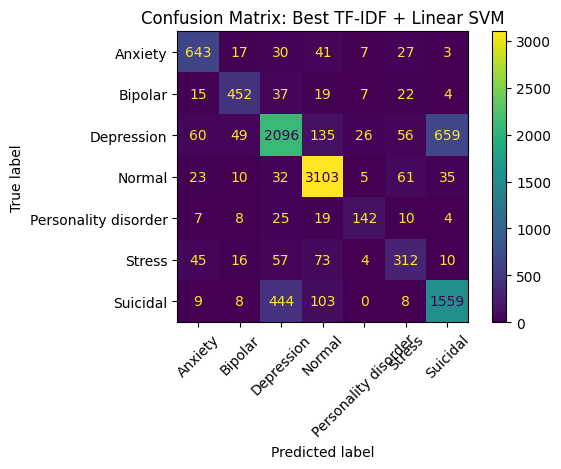

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params (LogReg): {'clf__C': 2.0, 'tfidf__max_features': 40000, 'tfidf__ngram_range': (1, 2)}

=== Best TF-IDF + Logistic Regression ===

Classification Report:
                      precision    recall  f1-score   support

             Anxiety     0.7970    0.8177    0.8072       768
             Bipolar     0.7770    0.8273    0.8014       556
          Depression     0.7966    0.6482    0.7147      3081
              Normal     0.9031    0.9299    0.9164      3269
Personality disorder     0.6220    0.7116    0.6638       215
              Stress     0.5552    0.7099    0.6231       517
            Suicidal     0.6836    0.7626    0.7209      2131

            accuracy                         0.7849     10537
           macro avg     0.7335    0.7725    0.7496     10537
        weighted avg     0.7904    0.7849    0.7843     10537

Accuracy: 0.7848533738255671


<Figure size 600x600 with 0 Axes>

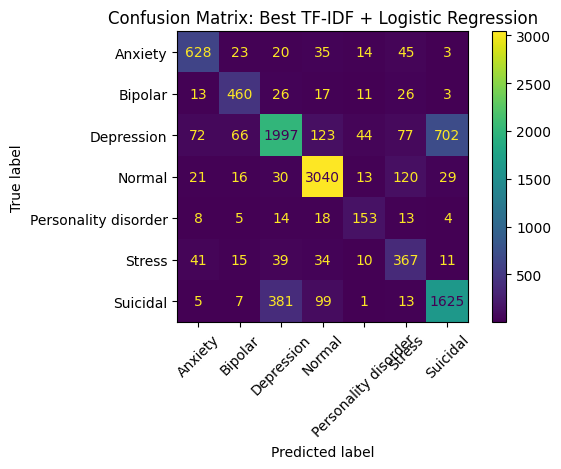

In [34]:
# Grid Search for Linear SVM
param_grid_svc = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_features': [20000, 40000, 80000],
    'clf__C': [0.5, 1.0, 2.0]
}

grid_svc = GridSearchCV(
    estimator=Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LinearSVC(class_weight='balanced'))
    ]),
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)

print('Best params (SVC):', grid_svc.best_params_)
best_svc = grid_svc.best_estimator_

evaluate_model(best_svc, X_train, y_train, X_val, y_val, title='Best TF-IDF + Linear SVM')


# Grid Search for Logistic Regression (smaller grid to save time)
param_grid_log = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_features': [20000, 40000],
    'clf__C': [0.5, 1.0, 2.0]
}

grid_log = GridSearchCV(
    estimator=Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]),
    param_grid=param_grid_log,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train, y_train)

print('Best params (LogReg):', grid_log.best_params_)
best_log = grid_log.best_estimator_

evaluate_model(best_log, X_train, y_train, X_val, y_val, title='Best TF-IDF + Logistic Regression')


## 11. Feature Importance: Top Words per Class (Logistic Regression)

In [35]:
def show_top_terms_per_class(pipe, n=20):
    """
    Show top n terms per class for classifiers with coef_ (LogisticRegression, LinearSVC).
    """
    if 'tfidf' not in pipe.named_steps or 'clf' not in pipe.named_steps:
        print("Pipeline must have 'tfidf' and 'clf' steps.")
        return
    
    tfidf = pipe.named_steps['tfidf']
    clf   = pipe.named_steps['clf']

    if not hasattr(clf, "coef_"):
        print(f"Classifier {type(clf).__name__} does not expose coefficients. Skipping.")
        return

    feature_names = np.array(tfidf.get_feature_names_out())
    classes = clf.classes_
    coefs = clf.coef_

    # Handle binary vs multi-class
    if coefs.ndim == 1:  # binary classifier
        coefs = np.vstack([-coefs, coefs])

    for idx, cls in enumerate(classes):
        class_coefs = coefs[idx]
        top_idx = np.argsort(class_coefs)[-n:][::-1]
        print(f"\nTop {n} terms for class '{cls}':")
        for i in top_idx:
            print(f'{feature_names[i]}\t{class_coefs[i]:.4f}')

# Example usage:
show_top_terms_per_class(best_log, n=20)   # Logistic Regression
show_top_terms_per_class(best_svc, n=20)   # Linear SVM



Top 20 terms for class 'Anxiety':
anxiety	13.3122
restless	12.5667
anxious	9.7440
worried	9.3265
nervous	8.7784
worry	6.4117
cancer	5.5607
restlessness	4.8121
health anxiety	4.7473
heart	4.5835
health	4.5656
symptoms	4.2521
scared	3.5911
worrying	3.4971
worries	3.3510
healthy	3.2080
fear	3.1440
freaking	3.1210
doctor	3.0837
about	3.0281

Top 20 terms for class 'Bipolar':
bipolar	19.0804
manic	11.6984
meds	8.1659
episode	8.0327
mania	7.6260
lamictal	6.5903
hypomanic	6.5851
lithium	6.2092
bp	5.5378
stable	5.2843
hypomania	5.1556
episodes	5.0623
latuda	5.0359
seroquel	4.9552
my meds	4.4459
mood	4.4389
illness	4.3060
abilify	3.7811
ve	3.6318
diagnosed	3.6169

Top 20 terms for class 'Depression':
depression	16.9205
wa	10.4155
am	7.5307
do not	7.4643
depressed	7.1275
cannot	6.1464
not	5.8302
ha	5.2757
doe	4.4668
pression	3.7795
did not	3.5120
http co	3.4757
life	3.2544
thing	3.1513
friend	3.1207
its	3.0718
it is	2.9549
symptom	2.9008
le	2.8637
parent	2.8505

Top 20 terms for class 'Normal':

## 12. Save & Load the Best Model

In [36]:
import os
import joblib

# Create a folder "models" if it doesn't exist
os.makedirs("models", exist_ok=True)

# Define save paths
MODEL_PATH_SVC = "models/mental_health_best_svc.joblib"
MODEL_PATH_LOG = "models/mental_health_best_log.joblib"

# Save models
joblib.dump(best_svc, MODEL_PATH_SVC)
joblib.dump(best_log, MODEL_PATH_LOG)
print(f"Saved models to: \n- {MODEL_PATH_SVC}\n- {MODEL_PATH_LOG}")

# Load & test SVC
loaded_svc = joblib.load(MODEL_PATH_SVC)
print("\nLoaded SVC. Predicting 3 samples from validation set:")
print(loaded_svc.predict(X_val[:3]))

# Load & test Logistic Regression
loaded_log = joblib.load(MODEL_PATH_LOG)
print("\nLoaded Logistic Regression. Predicting 3 samples from validation set:")
print(loaded_log.predict(X_val[:3]))


Saved models to: 
- models/mental_health_best_svc.joblib
- models/mental_health_best_log.joblib

Loaded SVC. Predicting 3 samples from validation set:
['Suicidal' 'Bipolar' 'Suicidal']

Loaded Logistic Regression. Predicting 3 samples from validation set:
['Suicidal' 'Bipolar' 'Suicidal']


## 13. Inference: Predict on New Text

In [37]:
def predict_condition(texts, model=None, model_path=MODEL_PATH_SVC):
    """
    Predicts mental health condition(s) for given text(s).

    Args:
        texts (str or list): Input text(s).
        model: Preloaded model pipeline. If None, loads from model_path.
        model_path (str): Path to saved model.

    Returns:
        list of (text, prediction)
    """
    if model is None:
        model = joblib.load(model_path)

    # Ensure input is list
    texts = [texts] if isinstance(texts, str) else list(texts)

    preds = model.predict(texts)
    return list(zip(texts, preds))


# Example predictions
samples = [
    "I've been feeling overwhelmed and anxious lately, can't sleep at night.",
    "Life has been really good and I'm excited about the future!",
    "I feel empty and can't focus on anything.",
    "i am so happy today",
    "Today was a stressful day",
    "Im restless for about a month",
    "My brain is about to burst, its too much pressure now on me",
    "I laughed with my friends today, but the moment I got home, the emptiness swallowed me again."
]

print("Predictions with SVC model:")
print(predict_condition(samples, loaded_svc))

print("\nPredictions with Logistic Regression model:")
print(predict_condition(samples, loaded_log, model_path=MODEL_PATH_LOG))


Predictions with SVC model:
[("I've been feeling overwhelmed and anxious lately, can't sleep at night.", 'Anxiety'), ("Life has been really good and I'm excited about the future!", 'Normal'), ("I feel empty and can't focus on anything.", 'Normal'), ('i am so happy today', 'Normal'), ('Today was a stressful day', 'Stress'), ('Im restless for about a month', 'Anxiety'), ('My brain is about to burst, its too much pressure now on me', 'Anxiety'), ('I laughed with my friends today, but the moment I got home, the emptiness swallowed me again.', 'Normal')]

Predictions with Logistic Regression model:
[("I've been feeling overwhelmed and anxious lately, can't sleep at night.", 'Anxiety'), ("Life has been really good and I'm excited about the future!", 'Normal'), ("I feel empty and can't focus on anything.", 'Normal'), ('i am so happy today', 'Suicidal'), ('Today was a stressful day', 'Normal'), ('Im restless for about a month', 'Anxiety'), ('My brain is about to burst, its too much pressure no